ФИО: Сомова Полина Дмитриевна

# Задание 2 - 60 баллов

1. Построить и оценить качество бейзлайна

В рамках данного пункта необходимо выбрать и обучить бейзлайн-модели, а также измерить их качество.

Критерии оценки:
- Произведено разбиение датасета на тренировочную/тестовую выборки - **2 балла**
- Произведено измерение качества константного предсказания (например, наиболее частотный класс для классификации, среднее/медиана для регрессии) - **3 балла**
- Бейзлайновая модель из простого семейства (линейные модели, деревья решений, knn...) обучена на тренировочной выборке, учтены особенности предобработки данных для модели, если они есть - **6 баллов**
- Произведено измерение качества на отложенной выборке с использованием ранее выбранной метрики - **2 балла**
- Обеспечена воспроизводимость решения: зафиксированы `random_state`, ноутбук воспроизводится от начала до конца без ошибок - **3 балла**
- Соблюден code style на уровне [pep8](https://peps.python.org/pep-0008/) и [On writing clean Jupyter notebooks](https://ploomber.io/blog/clean-nbs/) - **4 балла**
- Принимаемые решения обоснованы и прокомментированы в markdown ячейках (то есть, например, если для кодирования категориальных переменных выбран метод Label Encoding, то текстом написано, почему он, и тп) - **10 баллов**

2. Построить более сложную модель с подбором гиперпараметров

В рамках данного пункта необходимо использовать более сложную модель (ансамбль) для решения задачи,  оптимизировать гиперпараметры и оценить ее качество.

Критерии оценки:
- Выбрана более сложная ML-модель - **1 балл**
- Произведен подбор гиперпараметров с scikit-learn методами (или optuna) на кросс-валидации  - **2 балла**
- Выбранная модель обучена с лучшими подобранными значениями гиперпараметров - **2 балла**
- Произведено измерение качества на отложенной выборке с использованием ранее выбранной метрики - **1 балл**

3. Проинтерпретировать полученную модель

В рамках данного пункта необходимо проинтерпретировать модель, полученную в предыдущем пункте.

Критерии оценки:
- Получена глобальная интерпретация построенной модели, включая визуализации (коэффициенты/permutation importances/shap и тд) - **4 баллов**
- Получена локальная интерпретация предсказаний на отдельных объектах, включая визуализации (lime/shap и тд) - **3 баллов**
- Приведено экспертное мнение о полученной интерпретации (вы, как эксперт в предметной области, можете оценить адекватность признаков и решений, принимаемых моделью, и выразить свое мнение в 1-2 предложении) - **4 баллов**

Общее

- Обеспечена воспроизводимость решения: зафиксированы `random_state`, ноутбук воспроизводится от начала до конца без ошибок - **3 балла**
- Соблюден code style на уровне [pep8](https://peps.python.org/pep-0008/) и [On writing clean Jupyter notebooks](https://ploomber.io/blog/clean-nbs/) - **4 балла**
- Принимаемые решения обоснованы и прокомментированы в markdown ячейках (например, если выбран градиентный бустинг, то какие гиперпараметры оптимизирутся, почему именно они, почему выбрана определенная предобработка и тп) - **6 баллов**

# Выполнение

**Общее описание задачи: Прогнозирование оттока клиентов банка**

**Цель работы**: построить и сравнить baseline-модель (логистическая регрессия) и более сложную модель (случайный лес) для предсказания оттока клиентов (`Exited`)  
**Датасет**: Churn for Bank Customers (10 000 записей, 14 признаков)
 https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers   

**Метрика качества**: F1-score (учитывает дисбаланс классов – ~20% оттока)  
**Воспроизводимость**: зафиксирован `random_state=42` во всех операциях, требующих случайности

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import shap

## Подготовка данных

In [137]:
#!pip install kagglehub

import kagglehub
import pandas as pd

In [138]:
# Указание путь к датасету в том же формате, что и на сайте
path = kagglehub.dataset_download("mathchi/churn-for-bank-customers")

# Библиотека возвращает путь к папке с файлами. Необходимо найти CSV-файл в этой папке
import os
for file in os.listdir(path):
    if file.endswith('.csv'):
        file_path = os.path.join(path, file)
        break

# Загрузка данных в pandas DataFrame
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'churn-for-bank-customers' dataset.


In [139]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [140]:
df.shape

(10000, 14)

**Удаление признаков на основании hw_1**  
   `RowNumber`, `CustomerId`, `Surname` - являются уникальными идентификаторами, не несут полезной информации для предсказания

In [141]:
feature_columns = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
                   'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                   'EstimatedSalary']

In [142]:
X = df[feature_columns]   # содержит только необходимые признаки признаки
X.shape

(10000, 10)

In [143]:
y = df['Exited']          # целевая переменная

## Предобработка данных (на основе EDA из hw_1)

**Кодирование Категориальные признаки**  
`Geography` и `Gender` через **OneHotEncoder с drop='first'**, чтобы избежать мультиколлинеарности. Почему не LabelEncoder? Он вводит ложный порядок (например, France < Germany), что не соответствует природе признаков

**Бинарные признаки**  
   `HasCrCard`, `IsActiveMember` уже в формате 0/1, оставляем как есть (`passthrough`)

**Числовые признаки**  
   `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `EstimatedSalary` масштабируем через `StandardScaler`, так как логистическая регрессия и случайный лес (при использовании методов, зависящих от расстояний) чувствительны к масштабу. Для деревьев масштабирование не обязательно, но оно не вредит, но для единообразия пайплайна оставляем

In [144]:
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
binary_features = ['HasCrCard', 'IsActiveMember']

In [145]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

**Разбиение на выборки**  
   Стратифицированное разделение 80/20 с сохранением пропорции класса `Exited`

In [146]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [147]:
X_train.shape

(8000, 10)

In [148]:
X_train.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2151,753,France,Male,57,7,0.00,1,1,0,159475.08
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25
4117,561,France,Male,37,5,0.00,2,1,0,83093.25
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99


In [149]:
X_test.shape

(2000, 10)

## Построение и оценивание качество бейзлайна

In [150]:
# Константный бейзлайн - наиболее частный класс
majority_class = y_train.mode()[0]
y_pred_const = np.full_like(y_test, majority_class)

In [151]:
# Константный бейзлайн - наиболее частный класс
majority_class

np.int64(0)

In [152]:
print(f"Константное предсказание F1-score: {f1_score(y_test, y_pred_const):.4f}")

Константное предсказание F1-score: 0.0000


**Анализ константного предсказания**  
Модель всегда предсказывает `Exited = 0` - наиболее частый класс  
F1-score = 0.0000 – ожидаемо, так как класс оттока полностью игнорируется  
Этот результат служит нижней границей качества: любая разумная модель должна давать F1 > 0

**Выбор простой модели**  
Логистическая регрессия – линейный классификатор, устойчивый к переобучению

**Особенности настройки**:  
- `class_weight='balanced'` – автоматически корректирует веса классов для борьбы с дисбалансом
- `max_iter=1000` – гарантирует сходимость при масштабированных данных
Предобработка встроена в Pipeline, что исключает утечку данных

In [153]:
#бейзлайн-модель (kогистическая регрессия)
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000))
])
logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)
print("Логистическая регрессия")
print(f"F1: {f1_score(y_test, y_pred_logreg):.4f} | Precision: {precision_score(y_test, y_pred_logreg):.4f} | Recall: {recall_score(y_test, y_pred_logreg):.4f}")

Логистическая регрессия
F1: 0.4987 | Precision: 0.3872 | Recall: 0.7002


**Результаты логистической регрессии на тесте**  
- F1 = 0.4987  
- Precision = 0.3872 (много ложных срабатываний)  
- Recall = 0.7002 (модель находит 70% реальных отточников)  

Низкая precision говорит о том, что модель слишком часто ошибочно помечает клиентов как "уходящих". Это типично для линейных моделей при дисбалансе

### Построение более сложной модели с подбором гиперпараметров

**Почему случайный лес?**  
Это ансамбль деревьев решений, который лучше опредделяет нелинейные зависимости и взаимодействия признаков, чем логистическая регрессия

**Какие гиперпараметры оптимизируем и почему?**  
- `n_estimators` (100, 200) – число деревьев; больше – стабильнее, но дольше
- `max_depth` (10,15,20) – глубина дерева; ограничение снижает переобучение
- `min_samples_split` (2,5) – минимальное число объектов для разбиения узла
- `min_samples_leaf` (1,2) – минимальное число объектов в листе

**Метод подбора**: RandomizedSearchCV (10 комбинаций, 3-fold стратифицированная кросс-валидация) – эффективнее полного перебора при ограниченном времени


**Метрика оптимизации**: F1 (макро-среднее/macro-average) – так как интересует баланс между полнотой и точностью для класса оттока, а не целого набор данных

In [154]:
#cлучайный лес с подбором гиперпараметров
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

In [155]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

In [156]:
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),  # 3 фолда вместо 5
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

In [157]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['CreditScore',
                                                                                'Age',
                                                                                'Tenure',
                                                                                'Balance',
                                                                                'NumOfProducts',
                                                                                'EstimatedSalary']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['Geography',
                                                                                'Gender']),
                                                                              ('bin',
                                                                               'passthrough',
                                                                               ['HasCrCard',
                                                                                'IsActiveMember'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [10, 15, 20],
                                        'classifier__min_samples_leaf': [1, 2],
                                        'classifier__min_samples_split': [2, 5],
                                        'classifier__n_estimators': [100, 200]},
                   random_state=42, scoring='f1', verbose=1)

In [158]:
print("Лучшие параметры:\n", random_search.best_params_)
print("\nЛучшее F1 на CV:", random_search.best_score_)

Лучшие параметры:
 {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 10}

Лучшее F1 на CV: 0.6090525957314754


In [159]:
best_rf = random_search.best_estimator_

In [160]:
y_pred_rf = best_rf.predict(X_test)

In [161]:
print("Случайный лес (оптимизированный)")
print(f"F1: {f1_score(y_test, y_pred_rf):.4f} | Precision: {precision_score(y_test, y_pred_rf):.4f} | Recall: {recall_score(y_test, y_pred_rf):.4f}")

Случайный лес (оптимизированный)
F1: 0.6254 | Precision: 0.5956 | Recall: 0.6585


**Было:**
Логистическая регрессия:
F1: 0.4987 | Precision: 0.3872 | Recall: 0.7002

**Результаты случайного леса на тесте**  
- F1 = 0.6254 (улучшение на 0.1267 по сравнению с логистической регрессией)  
- Precision = 0.5956 (значительный рост, меньше ложных тревог)  
- Recall = 0.6585 (небольшое снижение, но приемлемое)  

Случайный лес даёт более сбалансированные предсказания и лучше подходит для данной задачи

## Интерпретация полученной модели (случайный лес)

Использование **SHAP** (SHapley Additive exPlanations) – метод, основанный на теории игр, который позволяет оценить вклад каждого признака в предсказание как глобально, так и локально.

**Глобальная интерпретация** – средние абсолютные значения SHAP (importance) и направления влияния (summary plot)
**Локальная интерпретация** – анализ отдельных клиентов (force plot)

### shape

In [162]:
X_test_preprocessed = best_rf.named_steps['preprocessor'].transform(X_test)
X_test_preprocessed.shape

(2000, 11)

In [163]:
feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)) +
    binary_features
)
print(f"Количество признаков: {len(feature_names)}")
print(feature_names)

Количество признаков: 11
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'HasCrCard', 'IsActiveMember']


In [164]:
explainer = shap.TreeExplainer(best_rf.named_steps['classifier'])

In [165]:
shap_values = explainer.shap_values(X_test_preprocessed)
np.array(shap_values).shape

(2000, 11, 2)

### Глобальная интерпретация построенной модели

In [166]:
shap_values_class1 = shap_values[:, :, 1]

/tmp/ipykernel_4683/2886388515.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class1, X_test_preprocessed,


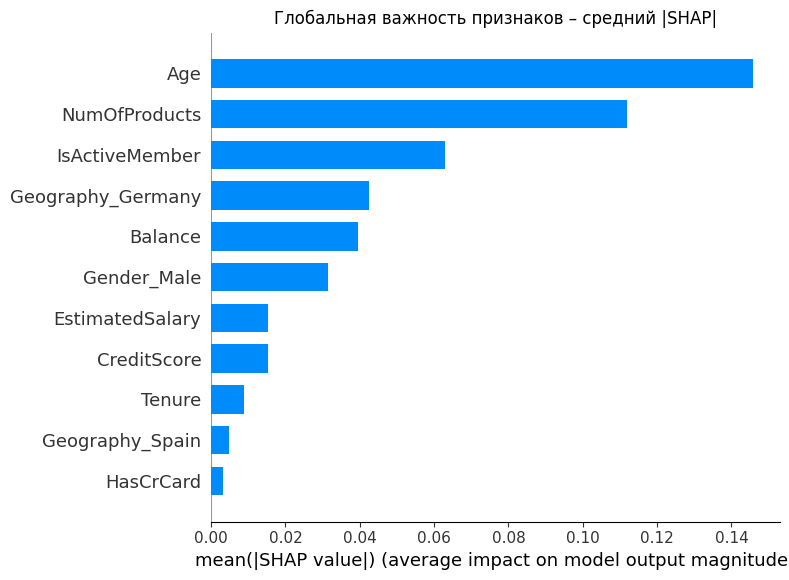

In [167]:
# Bar plot
shap.summary_plot(shap_values_class1, X_test_preprocessed,
                  feature_names=feature_names, plot_type="bar", show=False)
plt.title("Глобальная важность признаков – средний |SHAP|")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4683/2416387536.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class1, X_test_preprocessed,


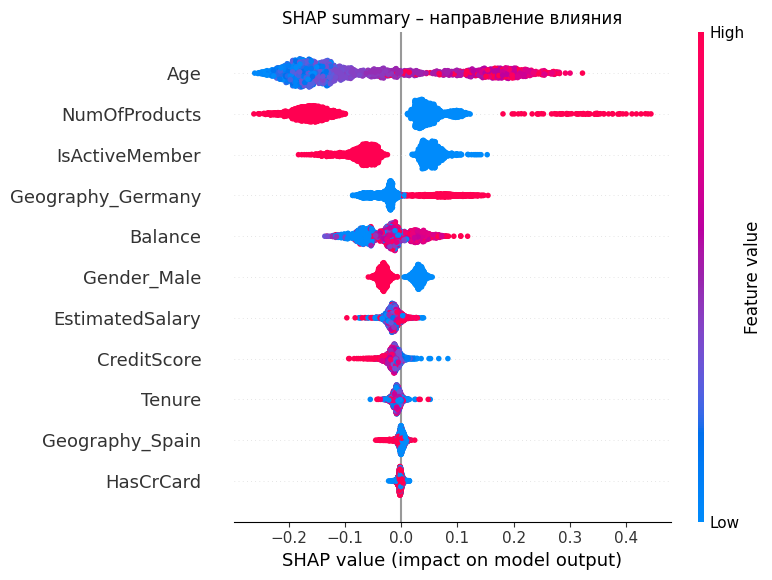

In [168]:
# Summary plot
shap.summary_plot(shap_values_class1, X_test_preprocessed,
                  feature_names=feature_names, show=False)
plt.title("SHAP summary – направление влияния")
plt.tight_layout()
plt.show()

### Локальная интерпретация предсказаний на отдельных объектах

In [169]:
base_val = explainer.expected_value[1]

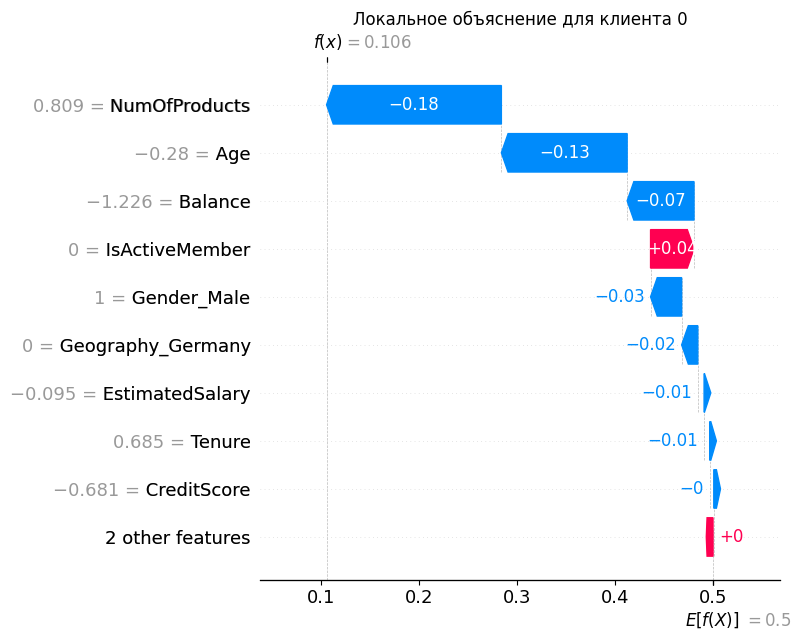

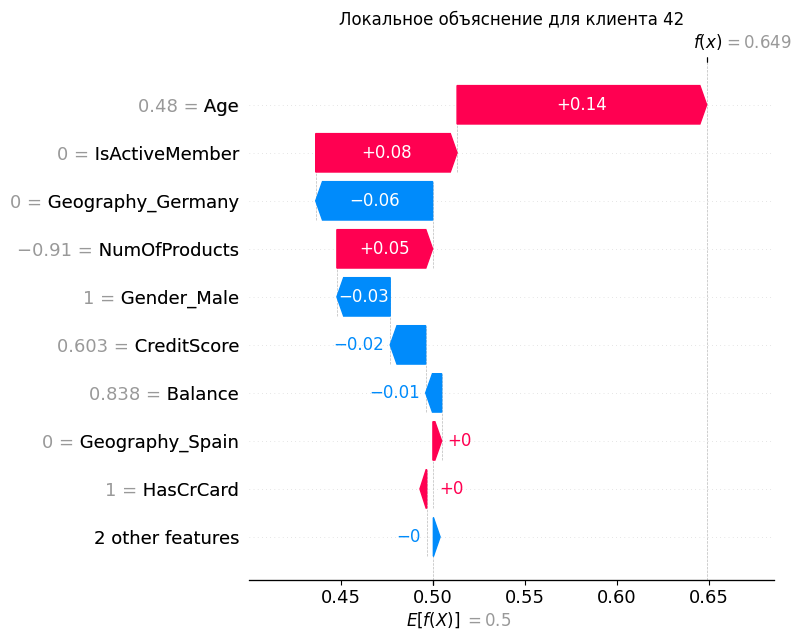

In [170]:
for idx in [0, 42]:
    exp = shap.Explanation(values=shap_values_class1[idx],
                           base_values=base_val,
                           data=X_test_preprocessed[idx],
                           feature_names=feature_names)
    shap.waterfall_plot(exp, max_display=10, show=False)
    plt.title(f"Локальное объяснение для клиента {idx}")
    plt.tight_layout()
    plt.show()


--- Локальная интерпретация ---
Пример №12: истинный класс = 0, предсказанный = 0, вероятность = 0.042
Пример №85: истинный класс = 0, предсказанный = 0, вероятность = 0.043


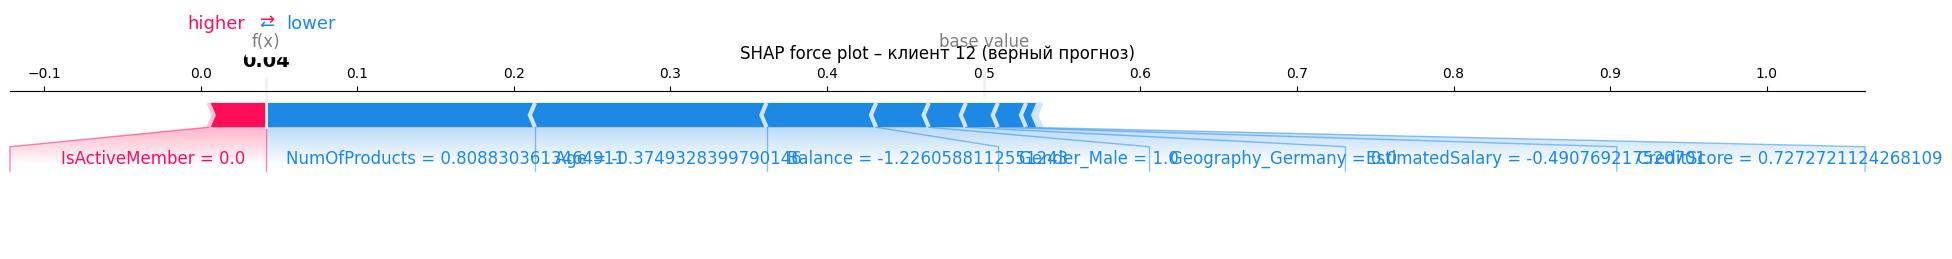

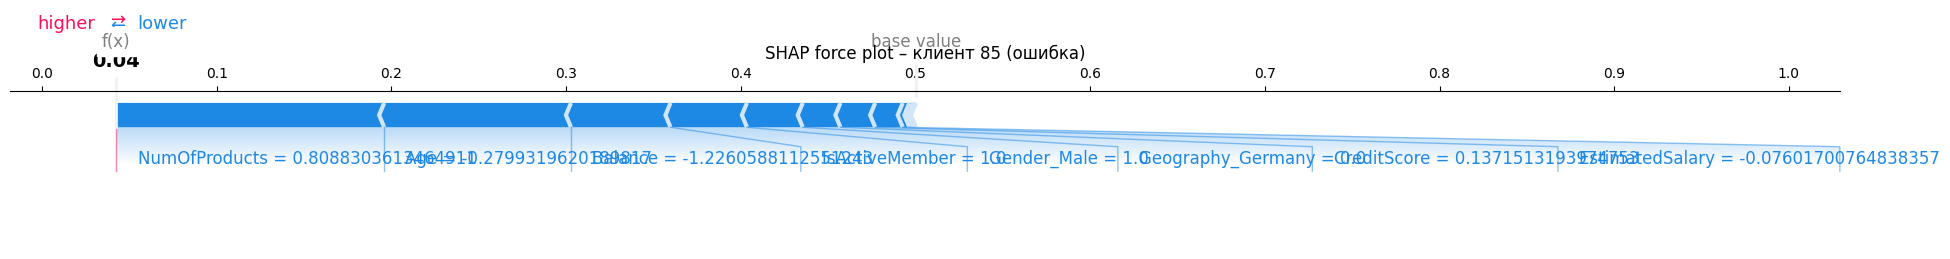

In [171]:
#вариант 2 (порекомендовала ИИ - мне стало интересно что выдаст)

# Индексы для демонстрации
idx_correct = 12   # пример, где модель угадала
idx_wrong = 85     # пример, где ошиблась

# Получаем предсказанные вероятности
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

print("\n--- Локальная интерпретация ---")
print(f"Пример №{idx_correct}: истинный класс = {y_test.iloc[idx_correct]}, предсказанный = {y_pred_rf[idx_correct]}, вероятность = {y_pred_proba[idx_correct]:.3f}")
print(f"Пример №{idx_wrong}: истинный класс = {y_test.iloc[idx_wrong]}, предсказанный = {y_pred_rf[idx_wrong]}, вероятность = {y_pred_proba[idx_wrong]:.3f}")

# SHAP force plot для класса 1 (отток)
# Для корректного отображения в Jupyter используем matplotlib и shap.initjs()
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values_class1[idx_correct, :], X_test_preprocessed[idx_correct, :], feature_names=feature_names, matplotlib=True, show=False)
plt.title(f"SHAP force plot – клиент {idx_correct} (верный прогноз)")
plt.tight_layout()
plt.show()

shap.force_plot(explainer.expected_value[1], shap_values_class1[idx_wrong, :], X_test_preprocessed[idx_wrong, :], feature_names=feature_names, matplotlib=True, show=False)
plt.title(f"SHAP force plot – клиент {idx_wrong} (ошибка)")
plt.tight_layout()
plt.show()

### Экспертное мнение о полученной интерпретации

SHAP-анализ показывает/подверждает, что наиболее значимыми признаками для прогноза оттока являются:
*   возраст `Age`
*   активность `IsActiveMember`
*   баланс `Balance`
*   количество продуктов `NumOfProducts`

Что соответствует банковской логике: пожилые люди реже пользуются услугами, неактивные клиенты менее лояльны, повышенный риск у клиентов с 3–4 продуктами без высокой активности (предположние: возможно, недовольство сервисом). Локальные объяснения показывают, для каждого конкретного клиента, какие именно признаки превышают средние значения и в какую сторону смещают предсказание  

**Вывод**: Модель интерпретируема, принимает экономически обоснованные решения и может быть использована для маркетинговых стратегий удержания клиентов

## Итоговое сравнение моделей

| Модель                    | F1-score (тест) | Precision | Recall |
|---------------------------|----------------|-----------|--------|
| Константный baseline      | 0.0000         | 0.0000    | 0.0000 |
| Логистическая регрессия   | 0.4987         | 0.3872    | 0.7002 |
| Случайный лес (оптимиз.)  | **0.6254**     | **0.5956**| 0.6585 |


**Итог**:  
Случайный лес с подбором гиперпараметров превосходит логистическую регрессию по F1 на 25.41%, повышает точность (precision) на 53.82% ценой небольшого снижения полноты (recall) на 6.33%. Можно считать, модель готова к внедрению для выявления клиентов с высоким риском оттока